## **Gradient Boosting for Classification from Scratch**

### **Topic Roadmap**

**1. Load a real binary classification dataset**

**2. Implement a regression stump**

**3. Use logistic-loss pseudo-residuals**

**4. Build an additive classifier**

**5. Key revision notes**

## **1. Binary Classification Data**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ads = pd.read_csv("docs/Lecture-088-Social_Network_Ads.csv")
x = ads["Age"].to_numpy(dtype=float)
y = ads["Purchased"].to_numpy(dtype=float)
order = np.argsort(x)
x, y = x[order], y[order]

## **2. Regression Stump for Pseudo-Residuals**

For binary logistic loss, the negative gradient is `y - p`, where `p` is the current predicted probability. A stump fits these continuous residuals.

In [3]:
def fit_stump(x, residual):
    thresholds = (x[:-1] + x[1:]) / 2
    best = None
    for threshold in thresholds:
        left = x <= threshold
        right = ~left
        if not left.any() or not right.any():
            continue
        left_value = residual[left].mean()
        right_value = residual[right].mean()
        update = np.where(left, left_value, right_value)
        loss = np.mean((residual - update) ** 2)
        if best is None or loss < best["loss"]:
            best = {"threshold": threshold, "left_value": left_value, "right_value": right_value, "loss": loss}
    return best

def stump_predict(stump, x):
    return np.where(x <= stump["threshold"], stump["left_value"], stump["right_value"])

def sigmoid(score):
    return 1 / (1 + np.exp(-np.clip(score, -40, 40)))

## **3. Gradient-Boosting Classification Loop**

The model stores an additive logit score. At every iteration, a stump fits the residuals and the score is updated by a shrinkage factor.

In [4]:
def gradient_boost_classifier(x, y, n_estimators=25, learning_rate=0.08):
    prior = np.clip(y.mean(), 1e-6, 1 - 1e-6)
    score = np.full(y.shape, np.log(prior / (1 - prior)), dtype=float)
    stumps = []
    for _ in range(n_estimators):
        probability = sigmoid(score)
        residual = y - probability
        stump = fit_stump(x, residual)
        score += learning_rate * stump_predict(stump, x)
        stumps.append(stump)
    return score.mean(), stumps

initial_score, stumps = gradient_boost_classifier(x, y)

In [5]:
def predict_probability(initial_score, stumps, x, learning_rate=0.08):
    score = np.full(x.shape, initial_score, dtype=float)
    for stump in stumps:
        score += learning_rate * stump_predict(stump, x)
    return sigmoid(score)

probabilities = predict_probability(initial_score, stumps, x)
predictions = (probabilities >= 0.5).astype(int)
print(f"Training accuracy: {np.mean(predictions == y):.3f}")

Training accuracy: 0.840


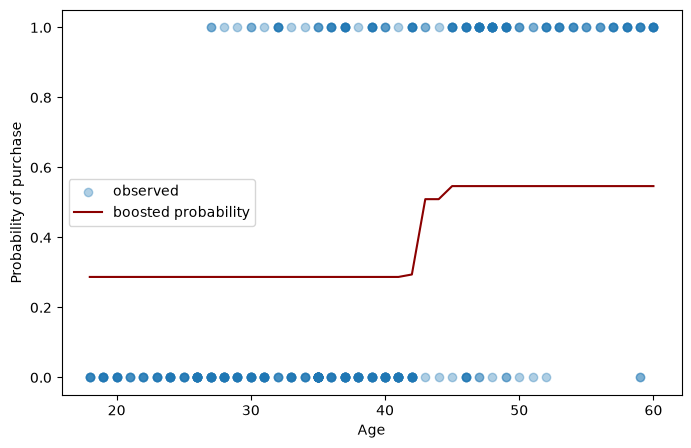

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.35, label="observed")
plt.plot(x, probabilities, color="darkred", label="boosted probability")
plt.xlabel("Age")
plt.ylabel("Probability of purchase")
plt.legend()
plt.show()

### **Key Revision Notes**

- Classification boosting maintains a score on the logit scale.
- The probability is obtained with the sigmoid function.
- The pseudo-residual is `y - p` for Bernoulli log loss.
- Each stump makes a small additive correction controlled by `learning_rate`.